# From Subhalos to Observed Satellites
## Part 2 — Observables and the observer

[Part 1](01_subhalos.ipynb) turned a dark-matter subhalo catalog into a population
of **galaxies with stellar masses**. That population is *intrinsic*: every galaxy that exists
around these hosts, whether or not anyone could ever see it.

No survey measures a stellar mass, and no survey sees a three-dimensional radius. This
notebook builds the rest of the chain.

| section | question | new model |
|---|---|---|
| **3** | what does the intrinsic population look like? | — |
| **4** | what would a telescope record? | $M_V$, $r_{1/2}$, $\langle\mu_V\rangle_e$ |
| **5** | where is the observer standing? | random projection |

$$P(\mathrm{data}\mid\mathrm{galaxies}) \;=\; \underbrace{P(\text{observable properties}\mid M_\star)}_{\text{Section 4}}\;\times\;\underbrace{P(\text{what the observer measures}\mid\text{properties})}_{\text{Section 5}}\;\times\;\underbrace{P(\text{detected}\mid\text{measured})}_{\text{Part 3}}$$

We stop just short of the last factor. Nothing in this notebook removes a galaxy for being too
faint — that is deliberate, and it is Part 3's job.

*Jiaxuan Li ([jiaxuanl@stanford.edu](mailto:jiaxuanl@stanford.edu)) — [github.com/elves-surveys/satellite_modeling_tutorial](https://github.com/elves-surveys/satellite_modeling_tutorial)*

---
## Setup

In [1]:
%load_ext autoreload
%autoreload 2
    
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import inspect

from src import io, galaxy_halo as gh, statistics as st, reference as ref, plotting as pl
from src import observables as ob, projection as pj

pl.use_tutorial_style()
rng = np.random.default_rng(42)     # fixed seed -> everyone sees the same mock

In [4]:
pwd

'/Users/jiaxuanl/Library/CloudStorage/Dropbox-Personal/Research/KICP_tutorial/notebooks'

In [5]:
hosts = io.load_hosts(data_dir='../data/', prefix='satgen_new_MW')
subs  = io.load_subhalos(data_dir='../data/', prefix='satgen_new_MW')
mpeak_min = 1e7                       # SatGen's resolution limit for this run

# the three host-mass bins used throughout, and the MW-like one we look at closely
HOST_BINS = [11.5, 12.0, 12.5]
LGM_MW, BINW = 12.0, 0.1

print(f"{len(hosts):,} hosts, {len(subs):,} subhalos, "
      f"log Mvir = {hosts.host_lgmvir.min():.2f} - {hosts.host_lgmvir.max():.2f}")

303 hosts, 2,333,215 subhalos, log Mvir = 11.50 - 12.50


---
# Section 3 — The intrinsic satellite population

Part 1 developed occupation and the SHMR one step at a time, in a single host-mass bin. Here we
run the whole thing over every host in one call.

$$\underbrace{\text{subhalo catalog}}_{\text{input}}
\;\xrightarrow{\;f_{\rm gal}(M_{\rm peak})\;}\;
\text{luminous subhalos}
\;\xrightarrow{\;M_\star(M_{\rm peak})+\epsilon\;}\;
\underbrace{\text{intrinsic satellites}}_{\text{this section}}$$

"Intrinsic" is the word to hold on to. Every galaxy in this table exists in the model; none of
them has yet been asked to be bright enough, big enough, or close enough to be found.

In [55]:
# One selection, one population call, all hosts.
sel  = io.select_satellites(subs, mpeak_min=mpeak_min, aperture="r_3d", f_rvir=1.0)
mock = gh.populate_subhalos(sel, occupation_params=gh.FIDUCIAL_OCCUPATION,
                            shmr_params=gh.FIDUCIAL_SHMR,
                            rng=np.random.default_rng(42))

print(f"{len(sel):,} subhalos with Mpeak > {mpeak_min:.0e} inside Rvir")
print(f"{len(mock):,} of them are luminous  ->  {len(mock)/len(hosts):.0f} satellites per host")
mock[["host_id", "host_lgmvir", "mpeak", "rvir_acc", "logmstar", "r_3d", "is_orphan"]].head(4)

1,645,758 subhalos with Mpeak > 1e+07 inside Rvir
265,733 of them are luminous  ->  877 satellites per host


,host_id,host_lgmvir,mpeak,rvir_acc,logmstar,r_3d,is_orphan
8,300,11.5,3.751862e+07,8.171309,1.306776,50.259830,False
24,300,11.5,9.554883e+09,52.078293,6.587274,98.789436,False
27,300,11.5,9.632501e+07,11.106154,2.519831,119.810333,False
47,300,11.5,8.750949e+07,10.268661,2.433742,170.209412,False


That is the intrinsic mock satellite catalog: one row per galaxy, with its host, its halo
properties, its stellar mass and its 3D position.

### 3.1: $N_{\rm sat}$ is a distribution, not a number

The first thing to ask of it is how the satellite count depends on host mass. The answer has to
be drawn as a *cloud*, not a curve.

In [56]:
THRESHOLDS = np.array([1e4, 1e6])          # Mstar thresholds, Msun
counts = st.per_host_counts(mock, THRESHOLDS, "mstar", host_ids=hosts.host_id.values)

nsat = pd.DataFrame(counts, columns=[f"n{int(np.log10(t))}" for t in THRESHOLDS])
nsat["lgmvir"] = hosts.host_lgmvir.values
# nsat.head(3)

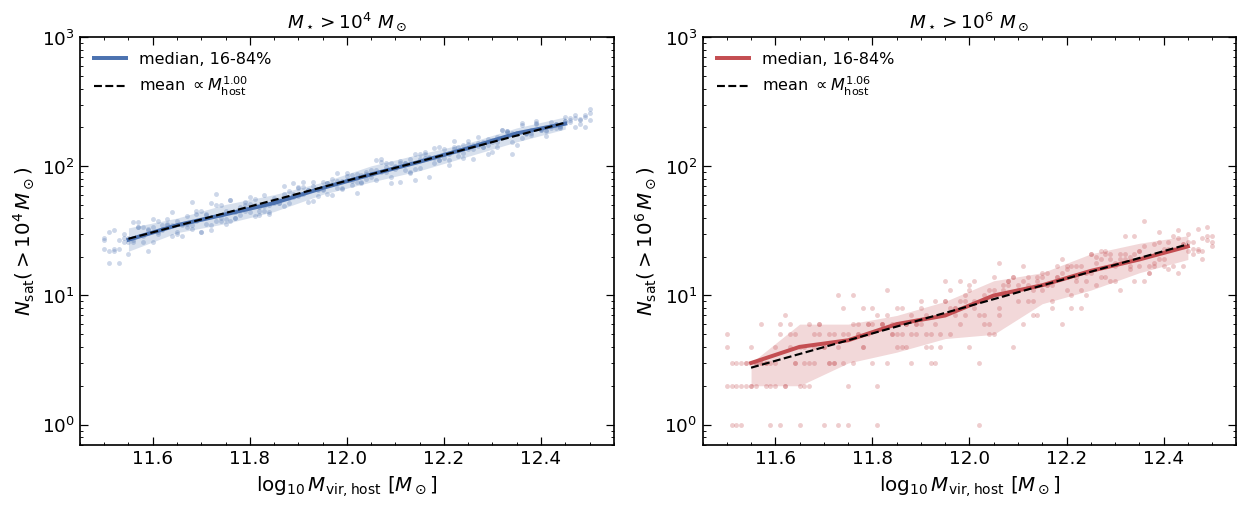

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

# The host grid is fine (0.01 dex, 3 realizations each), so bin it before taking
# percentiles -- three hosts is not enough to measure a 16-84% range.
bin_e = np.round(np.arange(11.5, 12.55, 0.1), 2)
ctr   = 0.5 * (bin_e[1:] + bin_e[:-1])
which = np.clip(np.digitize(nsat.lgmvir, bin_e) - 1, 0, len(ctr) - 1)

for ax, col, thr, c in [(axes[0], "n4", r"$10^4$", "#4C72B0"),
                        (axes[1], "n6", r"$10^6$", "#C44E52")]:
    # every host individually
    ax.plot(nsat.lgmvir, nsat[col], "o", ms=3.2, color=c, alpha=0.28, mew=0)
    band = np.array([np.percentile(nsat[col][which == i], [16, 50, 84])
                     for i in range(len(ctr))])
    ax.fill_between(ctr, band[:, 0], band[:, 2], color=c, alpha=0.22, lw=0)
    ax.plot(ctr, band[:, 1], color=c, lw=2.6, label="median, 16-84%")
    # a power law through the means, for scale
    mean = np.array([nsat[col][which == i].mean() for i in range(len(ctr))])
    s, b = np.polyfit(ctr, np.log10(mean), 1)
    ax.plot(ctr, 10**(s*ctr + b), "k--", lw=1.4,
            label=rf"mean $\propto M_{{\rm host}}^{{{s:.2f}}}$")
    ax.set(yscale="log", ylim=(0.7, 1e3), xlim=(11.45, 12.55),
           xlabel=r"$\log_{10} M_{\rm vir,host}\ [M_\odot]$",
           ylabel=rf"$N_{{\rm sat}}(>{thr[1:-1]}\,M_\odot)$")
    ax.set_title(rf"$M_\star > {thr[1:-1]}\ M_\odot$", fontsize=12)
    ax.legend(loc="upper left")
fig.tight_layout()

We can see two things:
1. **The mean scales close to linearly with host mass**.

2. **The scatter in $N_{\rm sat}$ is not small.**
At $\log M_{\rm vir}=12$, the 16–84% range spans 3 to 10 satellites with $M_\star > 10^{6} M_\odot$.
This width is a combination of both counting noise (Poisson) and host-to-host scatter from assembly histories. 

## 3.2: Satellite stellar mass function and luminosity function

Here we show the predicted stellar mass function and the luminosity function. We convert the $M_\star$ to $V$-band absolute magnitude assuming a fixed mass-to-light ratio of $$\Upsilon_V \equiv \frac{M_\star}{L_V} = 1.5, \qquad
M_V = M_{V,\odot} - 2.5\log_{10}\!\left(\frac{L_V}{L_\odot}\right),\quad M_{V,\odot}=4.83.$$

This is an oversimplified assumption. Old, metal-poor, roughly single-stellar-population dwarf populations sit near $\Upsilon_V\approx1.5$–$2$ (often a valid assumption for ultra-faint dwarfs); younger or more metal-rich ones fall below 1. A better approach is to model the assembly history and get the color of the satellite, then calculate the corresponding mass-to-light ratio.  

In [67]:
hid_mw = hosts.host_id[np.abs(hosts.host_lgmvir - LGM_MW) < BINW + 1e-9].values

# Convert the stellar mass to M_V using a fixed mass-to-light ratio of 1.5
mock_obs = ob.add_observables(mock, rng=np.random.default_rng(7))
mock_obs[["mpeak", "logmstar", "mv", "rvir_acc", "rhalf", "mu_eff"]].head(4)

mw_sats = mock_obs[mock_obs.host_id.isin(hid_mw)]

median N(M_V <  -2.5) =  212.0 per host
median N(M_V <  -5.0) =   67.0 per host
median N(M_V <  -8.0) =   18.0 per host


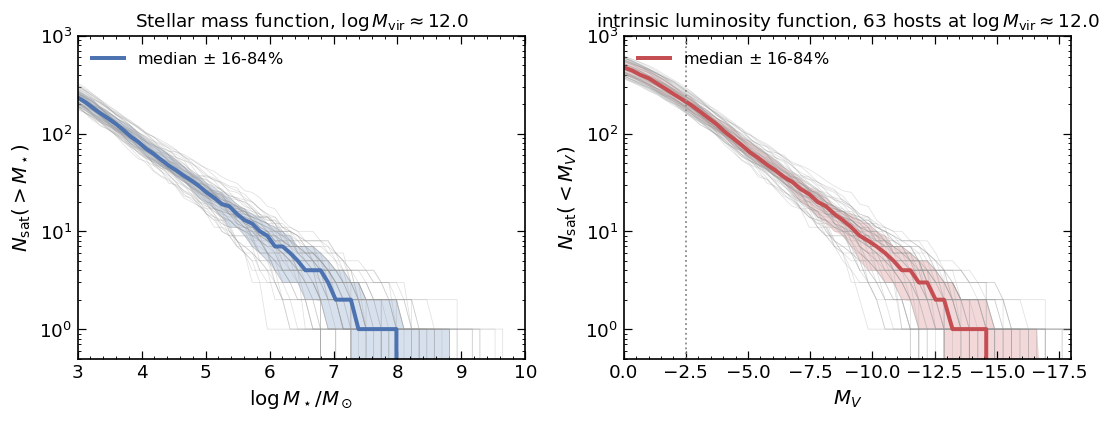

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))
### stellar mass function ###
ax = axes[0]
mstar_edges = np.linspace(3, 10, 60)
cnt_mstar = st.per_host_counts(mw_sats, mstar_edges, "logmstar", host_ids=hid_mw, direction="above")

for row in cnt_mstar:
    ax.plot(mstar_edges, row, color="0.6", lw=0.5, alpha=0.3)
pl.plot_band(ax, mstar_edges, cnt_mstar, color="#4C72B0", lw=2.6, label=r"median $\pm$ 16-84%")

ax.set(yscale="log", xlim=(3, 10), ylim=(0.5, 1e3),
       xlabel=r"$\log M_\star/M_\odot$", ylabel=r"$N_{\rm sat}(>M_\star)$")
ax.set_title(rf"Stellar mass function, "
             rf"$\log M_{{\rm vir}}\approx{LGM_MW}$", fontsize=12)
ax.legend(loc="upper left")

### M_V function ###
ax = axes[1]
mv_edges = np.linspace(0.0, -20.0, 60) 
cnt_mv = st.per_host_counts(mw_sats, mv_edges, "mv", host_ids=hid_mw, direction="below")
for row in cnt_mv:
    ax.plot(mv_edges, row, color="0.6", lw=0.5, alpha=0.3)
pl.plot_band(ax, mv_edges, cnt_mv, color="#C44E52", lw=2.6, label=r"median $\pm$ 16-84%")

ax.axvline(-2.5, color="0.55", ls=":", lw=1.2)

ax.set(yscale="log", xlim=(0, -18), ylim=(0.5, 1e3),
       xlabel=r"$M_V$", ylabel=r"$N_{\rm sat}(<M_V)$")
ax.set_title(rf"intrinsic luminosity function, {len(hid_mw)} hosts at "
             rf"$\log M_{{\rm vir}}\approx{LGM_MW}$", fontsize=12)
ax.legend(loc="upper left")
fig.tight_layout()

for thr in [-2.5, -5, -8]:
    n = np.median(st.per_host_counts(mw_sats, np.array([thr]), "mv",
                                     host_ids=hid_mw, direction="below"))
    print(f"median N(M_V < {thr:5.1f}) = {n:6.1f} per host")

---
# Section 4: Projection effects

So far, we have assumed an idealized case in which all satellites within the 3D virial radius can be identified. Real observations are more complicated.

For the Milky Way, satellite searches are limited by sky coverage and by detection completeness, which depends on apparent magnitude, surface brightness, size, and distance. For external hosts, including **ELVES, SAGA, and ELVES-Dwarf**, there is an additional complication: we generally cannot determine satellite positions precisely in 3D (SAGA, however, is more complicated). Instead, we observe a random projection of each system and select satellites within a projected galactocentric radius, $R_{\rm proj}$.

This introduces a simple **projection effect**. Objects at larger 3D radii can still project in the projected virial radius on the sky and enter the sample. Therefore, a radial cut like $R_{\rm proj}<R_{\rm vir}$ includes more objects than the 3D selection, with the excess coming from objects outside the 3D virial radius. In this section, we will see how to properly model this.

In [60]:
# Populate WITHOUT an aperture this time -- we need the objects outside Rvir,
# because they are exactly the ones that can project inward.
sel_wide  = io.select_satellites(subs, mpeak_min=mpeak_min, aperture=None)
mock_wide = gh.populate_subhalos(sel_wide, rng=np.random.default_rng(42))

proj = pj.project_satellites(mock_wide, rng=np.random.default_rng(11), 
                             d_los_max=800, r_max_rvir=5)
print(f"{len(mock_wide):,} luminous satellites -> {len(proj):,} within 5 Rvir (the guard cut)")
proj[["host_id", "mstar", "r_3d", "d_los", "r_proj_los", "r_proj_over_rvir"]].head(4)

363,708 luminous satellites -> 344,722 within 5 Rvir (the guard cut)


,host_id,mstar,r_3d,d_los,r_proj_los,r_proj_over_rvir
8,300,6.608173e+01,50.259830,46.365486,19.398257,0.109966
24,300,3.464903e+06,98.789436,89.428364,41.975236,0.237951
27,300,1.193801e+02,119.810333,23.359900,117.510983,0.666151
35,300,1.085900e+02,97.289482,-78.829666,57.018653,0.323230


## 4.1: Let's see the distribution of satellites selected in 3D vs in 2D

N(r_3D < Rvir)   = 9,745
N(R_proj < Rvir) = 10,652   ->  1.093x as many
of the projected sample, 8.5% lie outside Rvir in 3D


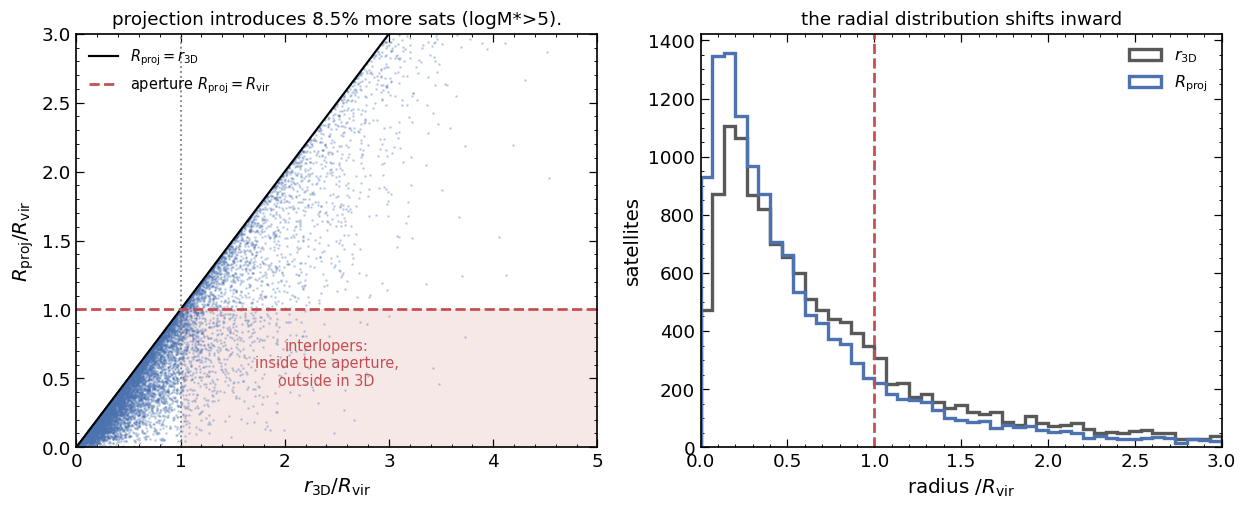

In [86]:
bright = proj[proj.mstar > 1e5]
# bright = bright[bright.rproj_over_rvir < 0.5]

rv = bright.host_rvir.values
in3d, inpr = bright.r_3d.values < rv, bright.r_proj_los.values < rv

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

ax = axes[0]
ax.plot(bright.r_3d/rv, bright.r_proj_los/rv, ".", ms=1.6, color="#4C72B0", alpha=0.25)
lim = np.linspace(0, 5, 10)
ax.plot(lim, lim, "k-", lw=1.4, label=r"$R_{\rm proj} = r_{\rm 3D}$")
ax.axhline(1, color="#C44E52", lw=1.8, ls="--", label=r"aperture $R_{\rm proj}=R_{\rm vir}$")
ax.axvline(1, color="0.5", lw=1.2, ls=":")
ax.fill_between([1, 5], 0, 1, color="#C44E52", alpha=0.13, lw=0)
ax.text(2.4, 0.45, "interlopers:\ninside the aperture,\noutside in 3D",
        ha="center", fontsize=9.5, color="#C44E52")
ax.set(xlim=(0, 5), ylim=(0, 3), xlabel=r"$r_{\rm 3D}/R_{\rm vir}$",
       ylabel=r"$R_{\rm proj}/R_{\rm vir}$")
ax.legend(loc="upper left", fontsize=9.5)
ax.set_title(f"projection introduces {100*(inpr & ~in3d).sum()/inpr.sum():.1f}% more sats (logM*>5).", fontsize=12)

ax = axes[1]
r_e = np.linspace(0, 3, 46)
ax.hist(bright.r_3d/rv, bins=r_e, histtype="step", lw=2.2, color="0.35", label=r"$r_{\rm 3D}$")
ax.hist(bright.r_proj_los/rv, bins=r_e, histtype="step", lw=2.2, color="#4C72B0",
        label=r"$R_{\rm proj}$")
ax.axvline(1, color="#C44E52", lw=1.8, ls="--")
ax.set(xlabel=r"radius $/ R_{\rm vir}$", ylabel="satellites", xlim=(0, 3))
ax.legend(loc="upper right"); ax.set_title("the radial distribution shifts inward", fontsize=12)
fig.tight_layout()

print(f"N(r_3D < Rvir)   = {in3d.sum():,}")
print(f"N(R_proj < Rvir) = {inpr.sum():,}   ->  {inpr.sum()/in3d.sum():.3f}x as many")
print(f"of the projected sample, {100*(inpr & ~in3d).sum()/inpr.sum():.1f}% lie outside Rvir in 3D")

A projected aperture returns about **~10% more satellites** than the same aperture in 3D. 
A real survey can't distinguish these objects from real satellites within the 3D virial radius, 
because membership criteria like velocities, surface-brightness-fluctuation (SBF) distances are not perfect. 
Whatever the survey does, the mock has to do the same, or the comparison is biased at the 10% level before any physics enters.


## 4.2 The same host, observed from many directions

across viewing directions: 67.1 +/- 2.1 (range 63-73), 3D truth 60
projection scatter is 3% of the mean, vs 18% host-to-host at fixed host mass


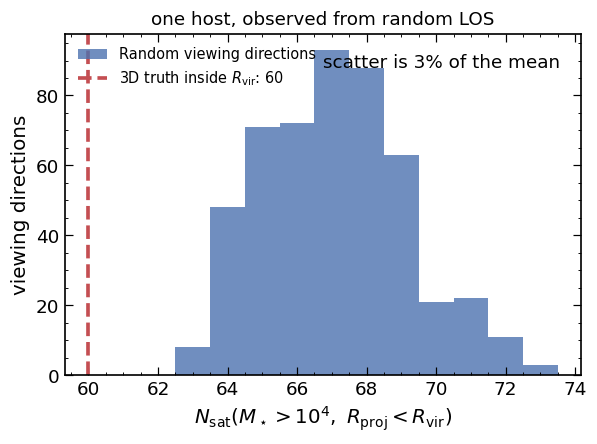

In [62]:
one_id = hid_mw[0]
one = mock_wide[(mock_wide.host_id == one_id) & (mock_wide.mstar > 1e4)]
rv_one = one.host_rvir.iloc[0]

n_view = 500
dirs = pj.random_viewing_direction(n_view, rng=np.random.default_rng(5))
xyz  = one[["x", "y", "z"]].to_numpy(float)
d_los = xyz @ dirs.T                                        # (n_sat, n_view)
r_pr  = np.sqrt((xyz**2).sum(1)[:, None] - d_los**2)
n_view_counts = (r_pr < rv_one).sum(axis=0)

n_true = int((one.r_3d < rv_one).sum())

fig, ax = plt.subplots(figsize=(5.6, 4.2))
ax.hist(n_view_counts, bins=np.arange(n_view_counts.min()-0.5, n_view_counts.max()+1.5),
        color="#4C72B0", alpha=0.8, label=f"Random viewing directions")
ax.axvline(n_true, color="#C44E52", lw=2.4, ls="--",
           label=rf"3D truth inside $R_{{\rm vir}}$: {n_true}")
ax.set(xlabel=r"$N_{\rm sat}(M_\star>10^4,\ R_{\rm proj}<R_{\rm vir})$",
       ylabel="viewing directions")
ax.set_title(f"one host, observed from random LOS", fontsize=12)
ax.legend(loc="upper left", fontsize=9.5)
fig.tight_layout()

# how does that compare with the host-to-host scatter at the same host mass?
mw_bin = np.abs(nsat.lgmvir - LGM_MW) < BINW + 1e-9
h2h = nsat.n4[mw_bin].std() / nsat.n4[mw_bin].mean()

print(f"across viewing directions: {n_view_counts.mean():.1f} +/- {n_view_counts.std():.1f} "
      f"(range {n_view_counts.min()}-{n_view_counts.max()}), 3D truth {n_true}")
ax.text(0.5, 0.9, f"scatter is {100*n_view_counts.std()/n_view_counts.mean():.0f}% of the mean", 
        transform=ax.transAxes)
print(f"projection scatter is {100*n_view_counts.std()/n_view_counts.mean():.0f}% of the mean, "
      f"vs {100*h2h:.0f}% host-to-host at fixed host mass")

**So projection adds only a few percent of scatter, against the much larger host-to-host variance.**


## 4.3: The projected radial profile

The other thing a survey measures is the *shape* of the distribution,
$N(<R_{\rm proj})/N(<R_{\rm vir})$. Normalizing divides the abundance out, which makes it
sensitive to the physics related to stripping and orbits and the effect of the host's potential
on the satellites.

The two panels below split the measurement in two:

- **left — abundance.** $N(<R_{\rm proj})$ per host, as a median and a host-to-host 16–84% band.
  This carries the counts information and grows steeply with host mass.
- **right — shape.** Normalize *each host* to its own $N(<R_{\rm vir})$ first, then average the
  normalized profiles over hosts (one vote per host). 

Normalizing per host keeps a well-populated and a sparse host on the same level. 

log Mvir=12.0:  28.8 sats/host, 63 hosts used, N(<0.5Rvir)/N(<Rvir) = 0.733 +/- 0.010


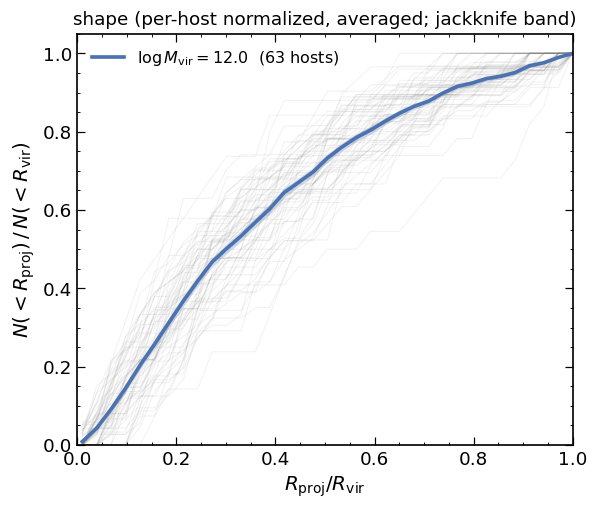

In [63]:
r_edges = np.linspace(0.01, 1.0, 35)
in_ap = proj[(proj.mstar > 1e5) & (proj.r_proj_over_rvir < 1.0)]

fig, ax = plt.subplots(figsize=(5.6, 4.8))
for c, lgm in zip(["#4C72B0", "#55A868", "#C44E52"], [12.0]):
    hid = hosts.host_id[np.abs(hosts.host_lgmvir - lgm) < BINW + 1e-9].values
    d   = in_ap[in_ap.host_id.isin(hid)]
    profiles = st.radial_profile(d, r_edges, host_ids=hid, normalize=True)
    for p in profiles:
        ax.plot(r_edges, p, color='gray', lw=0.7, alpha=0.1)

    prof, err, nhost = st.jackknife_profile(d, r_edges, host_ids=hid, min_sat=3)
    ax.fill_between(r_edges, prof - err, prof + err, color=c, alpha=0.25, lw=0)
    ax.plot(r_edges, prof, color=c, lw=2.4,
                 label=rf"$\log M_{{\rm vir}}={lgm}$  ({nhost} hosts)")

    k = np.argmin(abs(r_edges - 0.5))
    print(f"log Mvir={lgm}: {len(d)/len(hid):5.1f} sats/host, {nhost} hosts used, "
          f"N(<0.5Rvir)/N(<Rvir) = {prof[k]:.3f} +/- {err[k]:.3f}")

ax.set(xlabel=r"$R_{\rm proj}/R_{\rm vir}$", xlim=(0, 1))
ax.legend(loc="upper left")
ax.set(ylim=(0, 1.05), ylabel=r"$N(<R_{\rm proj})\,/\,N(<R_{\rm vir})$")
ax.set_title("shape (per-host normalized, averaged; jackknife band)", fontsize=12)
fig.tight_layout()

## 4.4: The Milky Way — from galactocentric to heliocentric distance

Everything above is the **extragalactic-host** geometry (for ELVES, SAGA-like surveys): the observer is far away, sees one random
projection, and measures a projected radius $R_{\rm proj}$. For the **Milky Way** the geometry is
different. We sit at about $R_\odot = 8.2$ kpc from the Galactic center, and the satellite's distance is typically reported as a **heliocentric** distance, not a galactocentric distance. 

However, there's a easy conversion between the two. 
`projection.place_mw_observer` does exactly this: it drops an observer at a random point
$R_\odot$ from the center of a given halo, then converts the galactocentric distances to a mock heliocentric one. 

A caveat: these SatGen runs have no disk, no bulge, so the halo has no
preferred plane and there is no physically meaningful place to put the Sun. 

In [64]:
one_id

np.int64(420)

In [76]:
# Select one MW-like host, seen from an observer 8.2 kpc off-centre.
mw_one = mw_sats[mw_sats.host_id == one_id].copy()
mw_one = mw_one[mw_one.r_3d < 3 * mw_one.host_rvir] # remove sats that are >3 Rvir from the host
mw_one = pj.place_mw_observer(mw_one, rng=np.random.default_rng(17))
mw_one[["mstar", "mv", "r_3d", "d_helio", "dm"]].head(4)

,mstar,mv,r_3d,d_helio,dm
377611,25007.650116,-5.724954,219.036453,226.934603,21.779504
377612,23177.827915,-5.642454,215.126221,215.077141,21.662971
377615,64.596726,0.744702,205.098145,202.786585,21.535196
377617,11647.121557,-4.895318,191.436615,197.322661,21.475885


 30.5% of this host's satellites (M* > 1e4) lie within  50 kpc of the Sun
 54.2% of this host's satellites (M* > 1e4) lie within 100 kpc of the Sun
100.0% of this host's satellites (M* > 1e4) lie within 300 kpc of the Sun


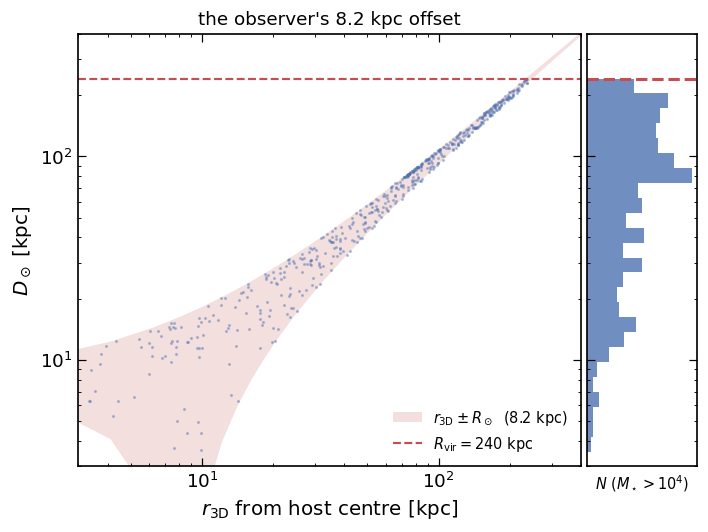

In [78]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(6.6, 5.0))

# main panel: the r_3D -> D_sun mapping
ax.plot(mw_one.r_3d, mw_one.d_helio, ".", ms=2.2, color="#4C72B0", alpha=0.35)
rr = np.linspace(0.1, 400, 200)
ax.fill_between(rr, np.abs(rr - pj.R_SUN), rr + pj.R_SUN, color="#C44E52", alpha=0.18, lw=0,
                label=rf"$r_{{\rm 3D}} \pm R_\odot$  ({pj.R_SUN} kpc)")
ax.set(xscale="log", yscale="log", xlim=(3, 400), ylim=(3, 400),
       xlabel=r"$r_{\rm 3D}$ from host centre [kpc]", ylabel=r"$D_\odot$ [kpc]")
ax.set_title(r"the observer's 8.2 kpc offset", fontsize=12)

axr = make_axes_locatable(ax).append_axes("right", size="22%", pad=0.05, sharey=ax)
axr.hist(mw_one.d_helio, bins=np.logspace(np.log10(3), np.log10(400), 30),
         orientation="horizontal", color="#4C72B0", alpha=0.8)
axr.axhline(mw_one.host_rvir.iloc[0], color="#C44E52", lw=2.0, ls="--")
ax.axhline(mw_one.host_rvir.iloc[0], color="#C44E52", lw=1.4, ls="--",
           label=rf"$R_{{\rm vir}} = {mw_one.host_rvir.iloc[0]:.0f}$ kpc")
axr.tick_params(axis="y", labelleft=False)
axr.set_xticks([])
axr.set_xlabel(r"$N\ (M_\star{>}10^4)$", fontsize=9.5)

ax.legend(loc="lower right", fontsize=9.5)
fig.tight_layout()

Beyond $\sim$100 kpc the offset is negligible and $D_\odot \approx r_{\rm 3D}$; inside
$\sim$30 kpc it is a factor-of-two effect. We should consider this effect when comparing with MW satellite searches. 

> ### Key lesson — Section 4
>
> The measurement geometry, not just the galaxy, decides what a survey records.
>
> | | external hosts (ELVES / SAGA-like) | Milky Way |
> |---|---|---|
> | what we measure | projected radius $R_{\rm proj}$ | heliocentric distance $D_\odot$ |
> | systematic it introduces | ~10% interlopers inside the aperture | none — we know where we sit |
> | random error it introduces | a few percent from the viewing angle | none — one geometry |
> | why it is still hard | many hosts, each shallow | one host, detection depends on $D_\odot$ |

---
## Exercises

**1. Where does the scatter in $N_{\rm sat}$ come from?** Section 3.1 showed a wide spread at
fixed host mass. Some of it is unavoidable counting noise: if satellites were sprinkled
independently with mean $\langle N\rangle$, we would already expect $\sigma=\sqrt{\langle N\rangle}$.
The rest is real variance in how much substructure the halo assembled:

$$\sigma_{\rm total}^2 = \underbrace{\langle N\rangle}_{\rm Poisson} + \sigma_{\rm intrinsic}^2 .$$

Run the two cells below. How does the intrinsic term grow with host mass? And if
$\sigma_{\rm intrinsic}$ does not average away by observing one host better, what does that say
about testing a model on the Milky Way alone?

In [80]:
# EXERCISE 1a -- the scatter budget as a function of host mass
print(f"{'log Mhost':>10}{'Nhost':>7}{'<N>':>8}{'sigma':>8}{'Poisson':>9}{'intrinsic':>11}{'sigma/<N>':>11}")
print("-" * 64)
for lgm in [11.6, 11.8, 12.0, 12.2, 12.4]:
    m = np.abs(nsat.lgmvir - lgm) < 0.101
    mean, sig, poi, intr = st.scatter_budget(nsat.n4[m].values)
    print(f"{lgm:10.1f}{m.sum():7d}{mean:8.2f}{sig:8.2f}{poi:9.2f}{intr:11.2f}{sig/mean:11.2f}")

 log Mhost  Nhost     <N>   sigma  Poisson  intrinsic  sigma/<N>
----------------------------------------------------------------
      11.6     63   31.81    6.84     5.64       3.86       0.21
      11.8     63   49.08    9.78     7.01       6.82       0.20
      12.0     63   78.81   14.40     8.88      11.33       0.18
      12.2     63  123.46   22.18    11.11      19.19       0.18
      12.4     63  198.46   31.68    14.09      28.38       0.16


observed spread is 1.6x wider than Poisson; one host constrains <N> to only +/-18%


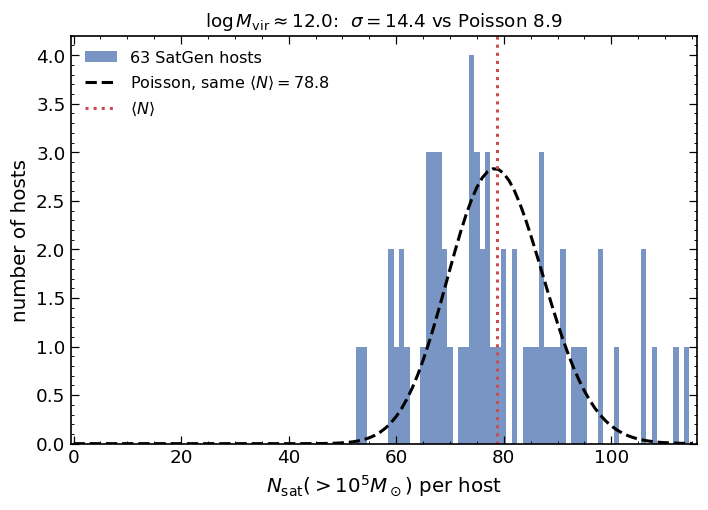

In [83]:
# EXERCISE 1b -- the same thing as a picture, in the MW-like bin
from scipy.stats import poisson as poisson_dist

n_mw = nsat.n4[np.abs(nsat.lgmvir - LGM_MW) < BINW + 1e-9].values
mean, sig, poi, intr = st.scatter_budget(n_mw)

fig, ax = plt.subplots(figsize=(6.6, 4.8))
ax.hist(n_mw, bins=np.arange(-0.5, n_mw.max() + 2.5), color="#4C72B0", alpha=0.75,
        label=f"{len(n_mw)} SatGen hosts")
k = np.arange(0, n_mw.max() + 2)
ax.plot(k, len(n_mw) * poisson_dist.pmf(k, mean), "k--", lw=2.0,
        label=rf"Poisson, same $\langle N\rangle={mean:.1f}$")
ax.axvline(mean, color="#C44E52", lw=2.0, ls=":", label=r"$\langle N\rangle$")
ax.set(xlabel=r"$N_{\rm sat}(>10^5 M_\odot)$ per host", ylabel="number of hosts",
       xlim=(-0.5, n_mw.max() + 2))
ax.set_title(rf"$\log M_{{\rm vir}} \approx {LGM_MW}$:  $\sigma={sig:.1f}$ vs Poisson ${poi:.1f}$",
             fontsize=12)
ax.legend(loc="upper left")
fig.tight_layout()

print(f"observed spread is {sig/poi:.1f}x wider than Poisson; "
      f"one host constrains <N> to only +/-{sig/mean*100:.0f}%")

**2. How much does $\Upsilon_V$ actually matter?** Section 4 asserted that the mass-to-light ratio
is the mildest knob in the tutorial. Check it: the cell below re-derives $M_V$ for three values
of $\Upsilon_V$ and counts satellites above three thresholds. Does the *shape* of the luminosity
function change, or only its position? Could a different $\Upsilon_V$ ever fix a count
discrepancy?

In [84]:
# EXERCISE 2
for ml in [1.0, 1.5, 2.5]:
    mv_try = ob.stellar_mass_to_mv(mw_sats.mstar.values, mass_to_light_v=ml)
    n = np.array([(mv_try < t).sum() / len(hid_mw) for t in [-2.5, -5, -8]])   # mean per host
    print(f"Upsilon_V = {ml:3.1f}:  N(<-2.5)={n[0]:6.1f}  N(<-5)={n[1]:5.1f}  N(<-8)={n[2]:5.1f}")

Upsilon_V = 1.0:  N(<-2.5)= 255.3  N(<-5)= 85.7  N(<-8)= 22.5
Upsilon_V = 1.5:  N(<-2.5)= 214.7  N(<-5)= 70.1  N(<-8)= 18.6
Upsilon_V = 2.5:  N(<-2.5)= 169.7  N(<-5)= 54.8  N(<-8)= 14.4


**3. Shrink the aperture.** ELVES does not search out to $R_{\rm vir}$ for every host; the
coverage is often closer to half of it. Re-run the interloper estimation with
`r_proj_over_rvir < 0.5` instead of 1.0. Does the interloper fraction go up or down, and why?